# 4 — Presentation view: local analysis, aggregate outputs

**Synthetic assessment data · descriptive exploration · no AI or network calls at runtime**

This final snapshot combines the reviewed preparation and visualization cells. For a live demo, run **Restart Kernel and Run All Cells** to show that the results are reproducible from the local CSV files.

## Privacy architecture

`student CSVs (local)` → `validation + pseudonyms (local)` → `analysis (memory only)` → `suppressed aggregates (display)`

An optional LLM helped draft generic code from schema descriptions. It never needed the CSVs, rows, names, IDs, outputs, or screenshots.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 20)


def locate_data_file(filename):
    """Find a data file when the notebook starts in /notebooks or the project root."""
    for folder in (Path.cwd(), Path.cwd().parent):
        candidate = folder / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename!r} in the current folder or its parent.")


reading_path = locate_data_file("FakeiReadyData.csv")
math_path = locate_data_file("FakeiReadyMathData.csv")

# Read identifiers as strings so leading zeros would be preserved in a real export.
reading_raw = pd.read_csv(
    reading_path,
    dtype={"Student Id": "string", "Class": "string"},
)
math_raw = pd.read_csv(
    math_path,
    dtype={"Student Id": "string", "Class": "string"},
)


SEASONS = ["Fall", "Winter", "Spring"]


def assessment_column(subject, measure, season):
    """Build the exact multiline heading used by the source CSV files."""
    return f"I-Ready Result\n{subject}\n{measure} - {season}\n2025-2026"


# Validate the proposed one-to-one join without displaying identifiers.
reading_ids = set(reading_raw["Student Id"].dropna())
math_ids = set(math_raw["Student Id"].dropna())
id_sets_match = reading_ids == math_ids

reading_demo = reading_raw.set_index("Student Id")
math_demo = math_raw.set_index("Student Id").rename(columns={"LEP": "MLL"})
demo_fields = [
    "Student Name", "Gender", "SWD", "MLL", "ED", "Current Grade", "Class"
]
if id_sets_match:
    mismatch_count = int(
        (
            reading_demo[demo_fields].sort_index().astype("string")
            != math_demo[demo_fields].sort_index().astype("string")
        ).sum().sum()
    )
else:
    mismatch_count = -1

validation = pd.DataFrame(
    {
        "check": [
            "Reading IDs are present and unique",
            "Math IDs are present and unique",
            "Reading and math ID sets match",
            "Shared demographic fields agree",
        ],
        "passed": [
            reading_raw["Student Id"].notna().all()
            and not reading_raw["Student Id"].duplicated().any(),
            math_raw["Student Id"].notna().all()
            and not math_raw["Student Id"].duplicated().any(),
            id_sets_match,
            mismatch_count == 0,
        ],
    }
)
assert validation["passed"].all(), "Stop and resolve join validation failures before analysis."

# Build stable aliases for this session. This is pseudonymization, not anonymization.
key_map = {
    student_id: f"S{number:03d}"
    for number, student_id in enumerate(sorted(reading_ids), start=1)
}

demographics = (
    reading_raw.assign(student_key=reading_raw["Student Id"].map(key_map))
    .rename(
        columns={
            "Gender": "gender",
            "SWD": "swd",
            "MLL": "mll",
            "ED": "economically_disadvantaged",
            "Current Grade": "current_grade",
            "Class": "class_section",
        }
    )[
        [
            "student_key",
            "gender",
            "swd",
            "mll",
            "economically_disadvantaged",
            "current_grade",
            "class_section",
        ]
    ]
)


def extract_scores(raw, subject):
    """Return one row per student and season for one subject."""
    frames = []
    prefix = subject.lower()
    for season in SEASONS:
        selected = raw[
            [
                "Student Id",
                assessment_column(subject, "Overall SS", season),
                assessment_column(subject, "Percentile", season),
                assessment_column(subject, "Overall Placement", season),
            ]
        ].copy()
        selected.columns = [
            "student_id",
            f"{prefix}_score",
            f"{prefix}_percentile",
            f"{prefix}_placement",
        ]
        selected["student_key"] = selected["student_id"].map(key_map)
        selected["season"] = season
        frames.append(selected.drop(columns="student_id"))
    return pd.concat(frames, ignore_index=True)


reading_scores = extract_scores(reading_raw, "Reading")
math_scores = extract_scores(math_raw, "Math")

analysis = (
    reading_scores.merge(
        math_scores,
        on=["student_key", "season"],
        how="inner",
        validate="one_to_one",
    )
    .merge(demographics, on="student_key", how="left", validate="many_to_one")
)
analysis["season"] = pd.Categorical(
    analysis["season"], categories=SEASONS, ordered=True
)
analysis = analysis.sort_values(["student_key", "season"]).reset_index(drop=True)

quality_checks = pd.DataFrame(
    {
        "check": [
            "Expected student-season row count",
            "One row per student and season",
            "Every student has all three seasons",
            "No direct identifiers in analysis table",
            "No missing overall scores",
        ],
        "passed": [
            len(analysis) == len(reading_ids) * len(SEASONS),
            not analysis.duplicated(["student_key", "season"]).any(),
            analysis.groupby("student_key", observed=True)["season"].nunique().eq(3).all(),
            {"Student Id", "Student Name"}.isdisjoint(analysis.columns),
            analysis[["reading_score", "math_score"]].notna().all().all(),
        ],
    }
)
assert quality_checks["passed"].all(), "Stop and resolve preparation failures before analysis."

In [2]:
student_columns = [
    "student_key",
    "gender",
    "swd",
    "mll",
    "economically_disadvantaged",
    "current_grade",
    "class_section",
]
student_info = analysis[student_columns].drop_duplicates()

score_wide = analysis.pivot(
    index="student_key",
    columns="season",
    values=["reading_score", "math_score"],
)
score_wide.columns = [
    f"{subject}_{season.lower()}" for subject, season in score_wide.columns
]

growth = student_info.merge(score_wide.reset_index(), on="student_key", validate="one_to_one")
growth["reading_growth"] = growth["reading_score_spring"] - growth["reading_score_fall"]
growth["math_growth"] = growth["math_score_spring"] - growth["math_score_fall"]

In [3]:
MIN_GROUP_SIZE = 10
subgroup_frames = []
for dimension, label in [
    ("gender", "Gender"),
    ("swd", "Students with disabilities"),
    ("mll", "Multilingual learners"),
    ("economically_disadvantaged", "Economically disadvantaged"),
]:
    part = (
        growth.groupby(dimension, dropna=False)
        .agg(
            n=("student_key", "size"),
            reading_growth=("reading_growth", "mean"),
            math_growth=("math_growth", "mean"),
        )
        .reset_index()
        .rename(columns={dimension: "group"})
    )
    part.insert(0, "dimension", label)
    subgroup_frames.append(part)

subgroup_internal = pd.concat(subgroup_frames, ignore_index=True)
eligible = subgroup_internal["n"].ge(MIN_GROUP_SIZE)
subgroup_display = subgroup_internal.assign(
    n=subgroup_internal["n"].astype("string").where(eligible, f"<{MIN_GROUP_SIZE}"),
    reading_growth=subgroup_internal["reading_growth"].where(eligible),
    math_growth=subgroup_internal["math_growth"].where(eligible),
)

## Data-quality gate

In [4]:
privacy_status = pd.DataFrame(
    {
        "item": [
            "Join and demographic checks",
            "Tidy-table checks",
            "Matched synthetic students",
            "Direct identifiers displayed",
            "Minimum displayed subgroup size",
        ],
        "status": [
            "PASS" if validation["passed"].all() else "STOP",
            "PASS" if quality_checks["passed"].all() else "STOP",
            f"{growth['student_key'].nunique():,}",
            "No",
            str(MIN_GROUP_SIZE),
        ],
    }
)
privacy_status

,item,status
0,Join and demographic checks,PASS
1,Tidy-table checks,PASS
2,Matched synthetic students,60
3,Direct identifiers displayed,No
4,Minimum displayed subgroup size,10


## At-a-glance metrics

In [5]:
def placement_as_grade(value):
    if value == "Kindergarten":
        return 0
    if isinstance(value, str) and value.startswith("Grade "):
        return int(value.split()[-1])
    return pd.NA


spring = analysis.loc[analysis["season"].eq("Spring")].copy()
spring["reading_placement_grade"] = spring["reading_placement"].map(placement_as_grade)
spring["math_placement_grade"] = spring["math_placement"].map(placement_as_grade)

kpis = pd.DataFrame(
    {
        "metric": [
            "Matched students",
            "Mean Reading growth",
            "Mean Math growth",
            "Spring Reading at/above current grade",
            "Spring Math at/above current grade",
        ],
        "value": [
            f"{growth['student_key'].nunique():,}",
            f"{growth['reading_growth'].mean():.1f} points",
            f"{growth['math_growth'].mean():.1f} points",
            f"{spring['reading_placement_grade'].ge(spring['current_grade']).mean():.1%}",
            f"{spring['math_placement_grade'].ge(spring['current_grade']).mean():.1%}",
        ],
    }
)
kpis

,metric,value
0,Matched students,60
1,Mean Reading growth,14.1 points
2,Mean Math growth,15.2 points
3,Spring Reading at/above current grade,33.3%
4,Spring Math at/above current grade,33.3%


## Aggregate dashboard

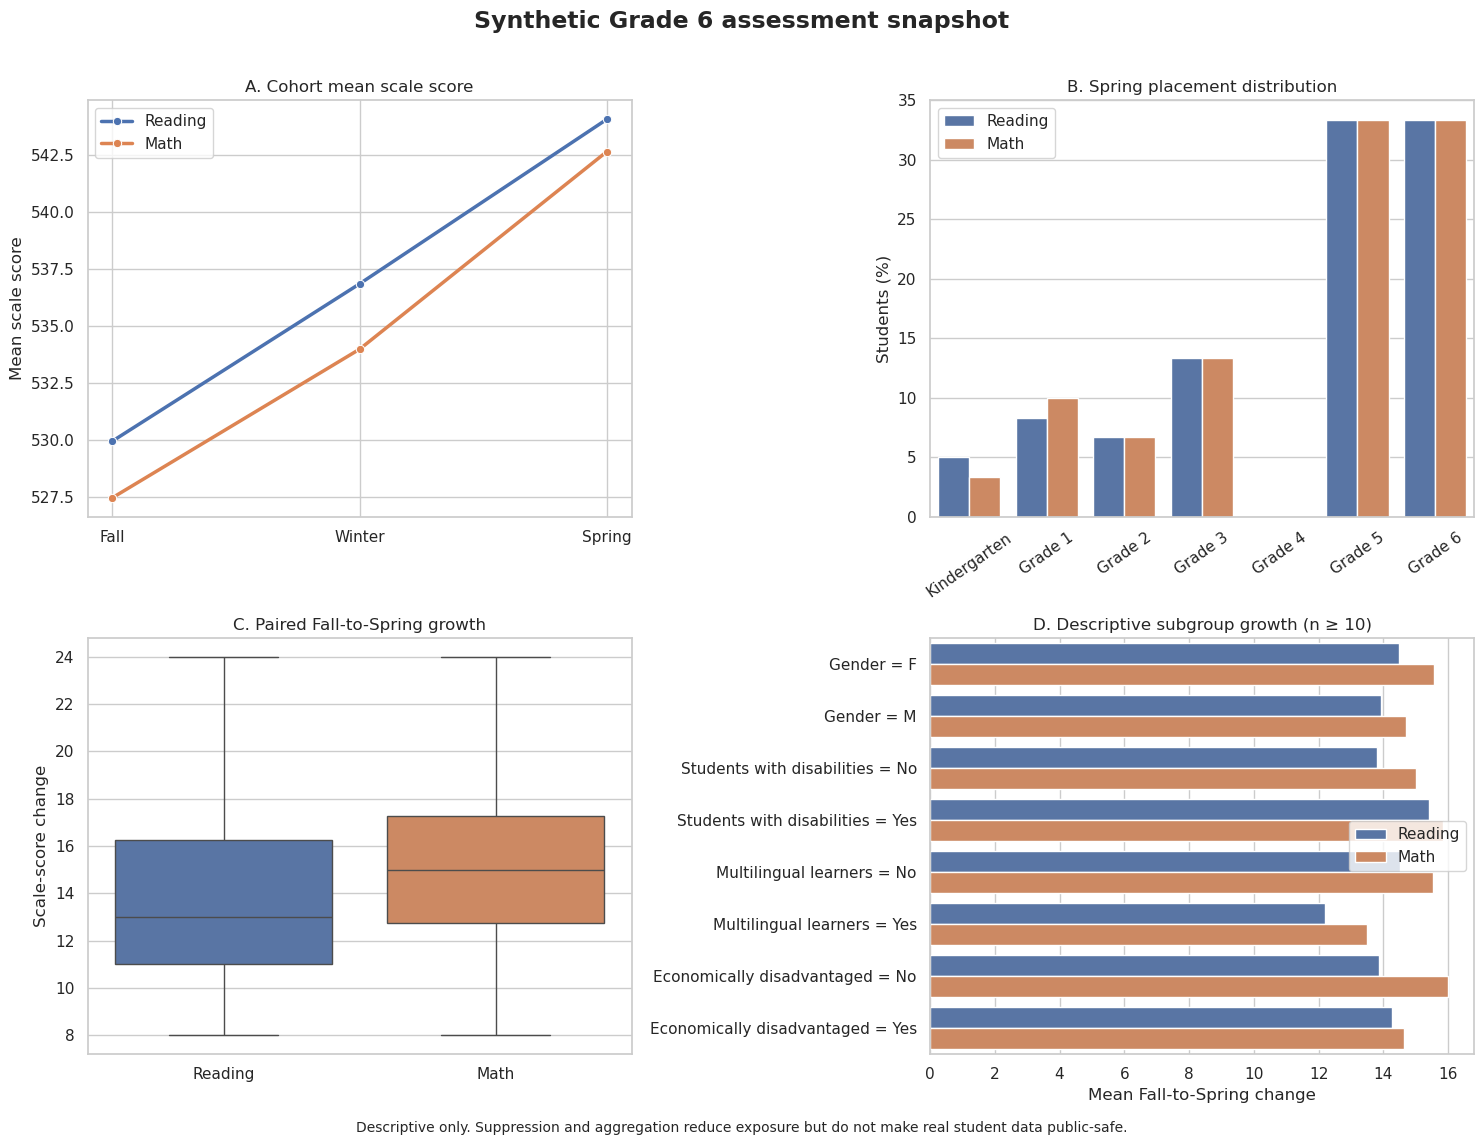

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
palette = {"Reading": "#4C72B0", "Math": "#DD8452"}

trend = (
    analysis.groupby("season", observed=True)[["reading_score", "math_score"]]
    .mean()
    .rename(columns={"reading_score": "Reading", "math_score": "Math"})
    .reset_index()
    .melt(id_vars="season", var_name="subject", value_name="mean_score")
)

placement_order = ["Kindergarten"] + [f"Grade {grade}" for grade in range(1, 7)]
placement_frames = []
for subject, column in [
    ("Reading", "reading_placement"),
    ("Math", "math_placement"),
]:
    percentages = (
        spring[column]
        .value_counts(normalize=True)
        .reindex(placement_order, fill_value=0)
        .mul(100)
        .rename("percent")
        .rename_axis("placement")
            .reset_index()
    )
    percentages["subject"] = subject
    placement_frames.append(percentages)
placement_summary = pd.concat(placement_frames, ignore_index=True)

growth_long = growth[["reading_growth", "math_growth"]].rename(
    columns={"reading_growth": "Reading", "math_growth": "Math"}
).melt(var_name="subject", value_name="growth")

chart_subgroups = subgroup_internal.loc[
    subgroup_internal["n"].ge(MIN_GROUP_SIZE)
].copy()
chart_subgroups["group_label"] = (
    chart_subgroups["dimension"] + " = " + chart_subgroups["group"].astype(str)
)
chart_subgroups = chart_subgroups.melt(
    id_vars=["dimension", "group", "group_label", "n"],
    value_vars=["reading_growth", "math_growth"],
    var_name="subject",
    value_name="mean_growth",
)
chart_subgroups["subject"] = chart_subgroups["subject"].map(
    {"reading_growth": "Reading", "math_growth": "Math"}
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sns.lineplot(
    data=trend,
    x="season",
    y="mean_score",
    hue="subject",
    palette=palette,
    marker="o",
    linewidth=2.5,
    ax=axes[0, 0],
)
axes[0, 0].set(
    title="A. Cohort mean scale score",
    xlabel="",
    ylabel="Mean scale score",
)
axes[0, 0].legend(title="")

sns.barplot(
    data=placement_summary,
    x="placement",
    y="percent",
    hue="subject",
    palette=palette,
    ax=axes[0, 1],
)
axes[0, 1].set(
    title="B. Spring placement distribution",
    xlabel="",
    ylabel="Students (%)",
)
axes[0, 1].tick_params(axis="x", rotation=35)
axes[0, 1].legend(title="")

sns.boxplot(
    data=growth_long,
    x="subject",
    y="growth",
    hue="subject",
    palette=palette,
    showfliers=False,
    legend=False,
    ax=axes[1, 0],
)
axes[1, 0].set(
    title="C. Paired Fall-to-Spring growth",
    xlabel="",
    ylabel="Scale-score change",
)

sns.barplot(
    data=chart_subgroups,
    y="group_label",
    x="mean_growth",
    hue="subject",
    palette=palette,
    ax=axes[1, 1],
)
axes[1, 1].set(
    title=f"D. Descriptive subgroup growth (n ≥ {MIN_GROUP_SIZE})",
    xlabel="Mean Fall-to-Spring change",
    ylabel="",
)
axes[1, 1].legend(title="")

fig.suptitle(
    "Synthetic Grade 6 assessment snapshot",
    fontsize=17,
    fontweight="bold",
    y=1.01,
)
fig.text(
    0.5,
    -0.01,
    "Descriptive only. Suppression and aggregation reduce exposure but do not make real student data public-safe.",
    ha="center",
    fontsize=10,
)
plt.tight_layout()
plt.show()

## Automatically calculated talking points

In [7]:
reading_growth_mean = growth["reading_growth"].mean()
math_growth_mean = growth["math_growth"].mean()
larger_subject = "Math" if math_growth_mean > reading_growth_mean else "Reading"
larger_value = max(reading_growth_mean, math_growth_mean)
reading_at_grade = spring["reading_placement_grade"].ge(spring["current_grade"]).mean()
math_at_grade = spring["math_placement_grade"].ge(spring["current_grade"]).mean()

display(
    Markdown(
        f"""
- The matched synthetic cohort's mean scale score rose from Fall to Spring in both subjects: **{reading_growth_mean:.1f} points in Reading** and **{math_growth_mean:.1f} points in Math**.
- **{larger_subject}** had the larger mean change ({larger_value:.1f} points), but no benchmark has been supplied for deciding whether that difference is educationally meaningful.
- In Spring, **{reading_at_grade:.1%}** were placed at or above current grade in Reading and **{math_at_grade:.1%}** in Math. Placement labels and growth should be interpreted with assessment guidance and local context.

These statements are descriptive and do not establish cause, program impact, or teacher effectiveness.
"""
    )
)


- The matched synthetic cohort's mean scale score rose from Fall to Spring in both subjects: **14.1 points in Reading** and **15.2 points in Math**.
- **Math** had the larger mean change (15.2 points), but no benchmark has been supplied for deciding whether that difference is educationally meaningful.
- In Spring, **33.3%** were placed at or above current grade in Reading and **33.3%** in Math. Placement labels and growth should be interpreted with assessment guidance and local context.

These statements are descriptive and do not establish cause, program impact, or teacher effectiveness.


## Privacy-by-default drill-down

Jupyter can support an authorized student-level follow-up without putting that view into a presentation. It is **off by default**. Even pseudonymous rows are sensitive and should not be screen-shared or exported casually.

In [8]:
SHOW_STUDENT_LEVEL = False  # Change only in an authorized, non-presented session.

if SHOW_STUDENT_LEVEL:
    follow_up = growth[
        [
            "student_key",
            "class_section",
            "reading_score_fall",
            "reading_score_spring",
            "reading_growth",
            "math_score_fall",
            "math_score_spring",
            "math_growth",
        ]
    ].sort_values("reading_growth")
    display(follow_up)
else:
    display(Markdown("🔒 Student-level display is off. Aggregate presentation mode is active."))

🔒 Student-level display is off. Aggregate presentation mode is active.

## What the LLM did—and did not do

**It did:** help propose generic analysis questions, pandas transformations, chart code, and caveats from a schema-only description.

**It did not:** receive the files, inspect rows, calculate results, choose an intervention, or validate the meaning of the assessment.

A human still had to review the join, run assertions, check privacy, interpret the output, and decide what was appropriate to present.

## Before repeating this with real student data

- Use only approved storage, devices, Jupyter environment, and AI tools.
- Do not paste rows, names, IDs, screenshots, outputs, errors, or local paths into an external assistant.
- Review generated code before running it; look for network, upload, file-write, and display operations.
- Minimize fields, suppress small groups, and treat aliases as sensitive.
- Validate joins and missingness before interpreting charts.
- Keep claims descriptive unless the design supports stronger inference.
- Apply assessment guidance, retention rules, and human educational judgment.